# Imports

In [4]:
import os
import time
import gc
import sys
import numpy as np
import pandas as pd
import psutil
import requests
from PIL import Image
from tqdm.notebook import tqdm

In [5]:
import cv2

In [3]:
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from transformers import (
    ViTModel, ViTImageProcessor,
    AutoImageProcessor, AutoModel,
    DeiTModel, DeiTImageProcessor,
    CLIPProcessor, CLIPVisionModel, CLIPTextModel,
    BertTokenizer, BertModel, 
    RobertaTokenizer, RobertaModel,
    GPT2Tokenizer, GPT2Model
)

In [7]:
import torch
from torchvision import models

# Configuration

In [8]:
#("Flickr8k", "Flickr30k", "ConceptualCaptions")
CURRENT_DATASET = "Flickr8k" 
ALL_DATASETS = ["Flickr8k", "Flickr30k", "ConceptualCaptions"]

# --- DIRECTORY ARCHITECTURE ---
DATA_DIR = os.path.join(os.getcwd(), 'TFE_Data')
DATASETS_DIR = os.path.join(DATA_DIR, 'Datasets')
RAW_DIR = os.path.join(DATA_DIR, 'Features_RAW')
RESULTS_DIR = os.path.join(DATA_DIR, 'Results')

# Create core directories
for d in [DATASETS_DIR, RAW_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

# Function to create dataset-specific saliency folders
def get_saliency_dir(dataset_name):
    path = os.path.join(DATA_DIR, f"SaliencyMaps_{dataset_name}")
    os.makedirs(path, exist_ok=True)
    return path

# Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Environment initialized. Using device: {device}")

Environment initialized. Using device: cuda


# Data Loading

In [9]:
print(f"Loading dataset: {CURRENT_DATASET}...")

df_path = os.path.join(DATASETS_DIR, f"df_{CURRENT_DATASET}.pkl")
if not os.path.exists(df_path):
    raise FileNotFoundError(f"Dataset file not found at {df_path}. Please run data_builder.ipynb first.")

df = pd.read_pickle(df_path)

# Extract inputs for models
IMAGE_PATHS = df['image_path'].tolist()
ALIGNED_CAPTIONS = [caps[0] for caps in df['captions']]

print(f"Ready. Loaded {len(IMAGE_PATHS)} images and {len(ALIGNED_CAPTIONS)} captions into memory.")

Loading dataset: Flickr8k...
Ready. Loaded 8091 images and 8091 captions into memory.


# Utility Functions
## GreenAI Metrics

In [10]:
def send_ntfy_notification(message, title="TFE Pipeline Update"):
    """Sends a push notification via ntfy.sh."""
    try:
        requests.post(
            f"https://ntfy.sh/{'aysel_tfe_server_9988'}",
            data=message.encode(encoding='utf-8'),
            headers={"Title": title}
        )
    except Exception as e:
        print(f"Notification failed: {e}")

def measure_memory():
    """Returns the current memory usage of the process in MB."""
    process = psutil.Process(os.getpid())
    return process.memory_info().rss / (1024 * 1024)

def get_size_in_mb(obj):
    """Returns the size of an object in MB."""
    return sys.getsizeof(obj) / (1024 * 1024)



In [11]:
def execute_and_save(modality, model_name, extract_func, data, device):
    """Measures metrics, extracts features + saliency, and saves results."""
    print(f"\nProcessing {modality.upper()} with model: {model_name}")
    start_time = time.time()
    mem_before = measure_memory()
    
    features = extract_func(data, device)
    
    exec_time = time.time() - start_time
    mem_used = max(0, measure_memory() - mem_before)
    
    save_path = os.path.join(RAW_DIR, f"X_{modality}_{model_name}_raw_{CURRENT_DATASET}.npy")
    np.save(save_path, features)
    
    print(f"Saved RAW features to: {save_path}")
    original_dim = features.shape[1]
    original_size = get_size_in_mb(features)
    
    del features
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
        
    return {
        "Modality": modality, "Model": model_name, "Original_Dim": original_dim,
        "Exec_Time_s": exec_time, "Memory_Used_MB": mem_used, "Original_Size_MB": original_size
    }

## XAI Saliency Maps

### Vision XAI

In [124]:
def save_saliency_and_overlay(model_name, activations, img_idx, img_path, dataset):
    """
    Captures pertinent zones using Norm-based weighting.
    Fixes the token dimension mismatch by explicitly removing the [CLS] token.
    """
    act = activations.detach().cpu()
    
    # --- CNN Logic (4D Tensors) ---
    if len(act.shape) == 4:
        weights = torch.norm(act, dim=1, keepdim=True)
        heatmap = torch.sum(act * weights, dim=1).squeeze().numpy()
        
    # --- Transformer Logic (3D Tensors) ---
    elif len(act.shape) == 3:
        # act shape: [1, 197, 768] (for DeiT/ViT)
        # We must remove the [CLS] token at index 0
        tokens = act[:, 1:, :]  # remove CLS

        # DeiT distilled → parfois 198 tokens
        if tokens.shape[1] == 197:
            tokens = tokens[:, :-1, :]
        
        # Calculate importance weights for the 196 patches
        weights = torch.norm(tokens, dim=-1, keepdim=True) # Shape: [1, 196, 1]
        
        # Apply weighting and sum feature dimensions -> Shape: [1, 196]
        weighted_sum = torch.sum(tokens * weights, dim=-1)
        
        # Calculate grid size (sqrt of 196 is 14)
        num_patches = tokens.shape[1]
        side = int(np.sqrt(num_patches)) 
        
        try:
            # Reshape exactly 196 elements into [14, 14]
            heatmap = weighted_sum.view(side, side).numpy()
        except RuntimeError:
            # Fallback if patch count is unexpected
            return
            
    else: return

    # Normalize heatmap 0-1
    heatmap = np.maximum(heatmap, 0)
    if np.max(heatmap) > 0: heatmap /= np.max(heatmap)
    heatmap_res = cv2.resize(heatmap, (224, 224))
    
    # Save Raw Saliency Map (.npy)
    saliency_dir = os.path.join(DATA_DIR, f"SaliencyMaps_{dataset}")
    os.makedirs(saliency_dir, exist_ok=True)
    np.save(os.path.join(saliency_dir, f"Saliency_{model_name}_{img_idx}.npy"), heatmap_res)
    
    # Save Visual Overlay 
    img_bgr = cv2.imread(img_path)
    img_bgr = cv2.resize(img_bgr, (224, 224))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_res), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(img_bgr, 0.6, heatmap_color, 0.4, 0)
    cv2.imwrite(os.path.join(RESULTS_DIR, f"Overlay_{dataset}_{model_name}_{img_idx}.jpg"), overlay)

### Text XAI

In [12]:
def save_text_saliency(tokens, scores, model_name, idx, dataset_name):
    save_dir = os.path.join(DATA_DIR, f"TextSaliency_{dataset_name}")
    os.makedirs(save_dir, exist_ok=True)

    path = os.path.join(
        save_dir,
        f"SaliencyText_{model_name}_{idx}.npy"
    )

    np.save(path, {"tokens": tokens, "scores": scores})

# Unimodal Models
## Indexing: Embedding Models

## Vision Feature Extractions

In [ ]:
class ImageDataset(torch.utils.data.Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        try:
            # 1. Force RGB at the PIL level
            image = Image.open(img_path).convert('RGB')
            
            # 2. Additional safety: check if PIL actually produced 3 channels
            if len(image.getbands()) != 3:
                image = image.convert('RGB')
                
        except Exception:
            # Placeholder for corrupted web-scraped images
            image = Image.new('RGB', (224, 224), (0, 0, 0)) 
            
        if self.transform:
            try:
                image = self.transform(image)
            except Exception:
                # If the transform still fails (rare), return a zero tensor
                return torch.zeros((3, 224, 224))
        return image

def extract_vision_features(model, model_name, dataloader, device, target_layer, paths, dataset_name):
    model.eval()
    features, activations = [], {}
    img_idx = 0
    safe_name = model_name.lower()

    # ✅ Hook défini proprement
    def hook_fn(module, input, output):
        if hasattr(output, "last_hidden_state"):
            activations['value'] = output.last_hidden_state
        elif isinstance(output, tuple):
            activations['value'] = output[0]
        else:
            activations['value'] = output

    # ✅ Hook enregistré ICI (et une seule fois)
    hook = target_layer.register_forward_hook(hook_fn)

    with torch.no_grad():
        for batch in tqdm(dataloader, desc=f"{safe_name}"):
            batch = batch.to(device)
            outputs = model(batch)

            # --- FEATURES ---
            if hasattr(outputs, 'last_hidden_state'):
                feat = outputs.last_hidden_state[:, 0, :]
            elif isinstance(outputs, torch.Tensor):
                feat = outputs[:, 0, :]
            else:
                feat = outputs[0][:, 0, :]

            features.append(feat.cpu().numpy())

            # --- SALIENCY ---
            batch_acts = activations.get('value')

            if batch_acts is None:
                print(f"[ERROR] Hook failed for {safe_name}")
                continue

            for i in range(batch_acts.size(0)):
                save_saliency_and_overlay(
                    safe_name,
                    batch_acts[i:i+1],
                    img_idx,
                    paths[img_idx],
                    dataset_name
                )
                img_idx += 1

            activations['value'] = None  # reset propre

    hook.remove()
    return np.vstack(features)

def get_resnet50_embeddings(paths, device, dataset):
    m = models.resnet50(weights="DEFAULT").to(device)
    t = m.layer4[-1] 
    m.fc = nn.Identity()
    loader = torch.utils.data.DataLoader(ImageDataset(paths, models.ResNet50_Weights.DEFAULT.transforms()), batch_size=32)
    return extract_vision_features(m, "resnet50", loader, device, t, paths, dataset)

def get_mobilenet_v3_embeddings(paths, device, dataset):
    m = models.mobilenet_v3_large(weights="DEFAULT").to(device)
    t = m.features[-1]
    m.classifier = nn.Identity()
    loader = torch.utils.data.DataLoader(ImageDataset(paths, models.MobileNet_V3_Large_Weights.DEFAULT.transforms()), batch_size=32)
    return extract_vision_features(m, "mobilenet_v3", loader, device, t, paths, dataset)

def get_vit_embeddings(paths, device, dataset):
    proc = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224-in21k')
    m = ViTModel.from_pretrained('google/vit-base-patch16-224-in21k').to(device)
    t = m.encoder.layer[-1]
    tf = lambda x: proc(images=x, return_tensors="pt")['pixel_values'].squeeze(0)
    loader = torch.utils.data.DataLoader(ImageDataset(paths, tf), batch_size=32)
    return extract_vision_features(m, "vit", loader, device, t, paths, dataset)


def get_deit_embeddings(image_paths, device, dataset_name):
    from transformers import DeiTImageProcessor, DeiTModel

    processor = DeiTImageProcessor.from_pretrained(
        'facebook/deit-base-distilled-patch16-224'
    )
    model = DeiTModel.from_pretrained(
        'facebook/deit-base-distilled-patch16-224'
    ).to(device)

    target_layer = model.encoder.layer[-1].output

    def transform(img):
        return processor(images=img, return_tensors="pt")['pixel_values'].squeeze(0)

    ds = ImageDataset(image_paths, transform=transform)
    dataloader = torch.utils.data.DataLoader(ds, batch_size=32, num_workers=4)

    return extract_vision_features(
        model,
        "deit",
        dataloader,
        device,
        target_layer,
        image_paths,
        dataset_name
    )

def get_clip_vision_embeddings(image_paths, device, dataset_name):
    processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')
    model = CLIPVisionModel.from_pretrained('openai/clip-vit-base-patch32').to(device)
    
    def transform(img): 
        return processor(images=img, return_tensors="pt")['pixel_values'].squeeze(0)
    
    ds = ImageDataset(image_paths, transform=transform)
    dataloader = torch.utils.data.DataLoader(ds, batch_size=32, num_workers=4)
    target_layer = model.vision_model.encoder.layers[-1]
    
    return extract_vision_features(
        model, 
        "clip_vision", 
        dataloader, 
        device, 
        target_layer, 
        image_paths, 
        dataset_name
    )

In [122]:
for ds in ALL_DATASETS:
    print(f"\n>>> FINAL ATTEMPT DeiT: {ds}")
    CURRENT_DATASET = ds # Reset global context
    
    df_temp = pd.read_pickle(os.path.join(DATASETS_DIR, f"df_{ds}.pkl"))
    current_paths = df_temp['image_path'].tolist()
    
    # Run the extraction
    execute_and_save("vision", "deit", lambda p, d: get_deit_embeddings(p, d, ds), current_paths, device)

    # Physical file check
    s_path = os.path.join(DATA_DIR, f"SaliencyMaps_{ds}")
    count = len([f for f in os.listdir(s_path) if "deit" in f])
    print(f"VERIFICATION: Found {count} DeiT maps in {ds}")


>>> FINAL ATTEMPT DeiT: Flickr8k

Processing VISION with model: deit


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

DeiTModel LOAD REPORT from: facebook/deit-base-distilled-patch16-224
Key                            | Status     | 
-------------------------------+------------+-
distillation_classifier.bias   | UNEXPECTED | 
cls_classifier.weight          | UNEXPECTED | 
distillation_classifier.weight | UNEXPECTED | 
cls_classifier.bias            | UNEXPECTED | 
pooler.dense.weight            | MISSING    | 
pooler.dense.bias              | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Forced Patch: deit:   0%|          | 0/253 [00:00<?, ?it/s]

Saved RAW features to: /home/aysel/tfe/TFE_Data/Features_RAW/X_vision_deit_raw_Flickr8k.npy
VERIFICATION: Found 0 DeiT maps in Flickr8k

>>> FINAL ATTEMPT DeiT: Flickr30k

Processing VISION with model: deit


...

Saved RAW features to: /home/aysel/tfe/TFE_Data/Features_RAW/X_vision_deit_raw_Flickr30k.npy
VERIFICATION: Found 0 DeiT maps in Flickr30k

>>> FINAL ATTEMPT DeiT: ConceptualCaptions

Processing VISION with model: deit


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

DeiTModel LOAD REPORT from: facebook/deit-base-distilled-patch16-224
Key                            | Status     | 
-------------------------------+------------+-
distillation_classifier.bias   | UNEXPECTED | 
cls_classifier.weight          | UNEXPECTED | 
distillation_classifier.weight | UNEXPECTED | 
cls_classifier.bias            | UNEXPECTED | 
pooler.dense.weight            | MISSING    | 
pooler.dense.bias              | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Forced Patch: deit:   0%|          | 0/1563 [00:00<?, ?it/s]

Saved RAW features to: /home/aysel/tfe/TFE_Data/Features_RAW/X_vision_deit_raw_ConceptualCaptions.npy
VERIFICATION: Found 0 DeiT maps in ConceptualCaptions


## T2T Text 


### Indexing: Embedding Models

In [ ]:
## Text Feature Extraction
class TextDataset(torch.utils.data.Dataset):
    def __init__(self, texts, tokenizer, max_length=128):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer(
            text, truncation=True, padding='max_length',
            max_length=self.max_length, return_tensors='pt'
        )
        return {key: val.squeeze(0) for key, val in encoding.items()}

def extract_text_features(model, dataloader, device, tokenizer, model_name, dataset_name, feature_type='last_hidden_state_mean'):
    model.eval()
    features = []
    xai_index = 0
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Extracting Text"):
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            
            # Embedding
            if feature_type == 'last_hidden_state_mean':
                attention_mask = batch['attention_mask'].unsqueeze(-1).expand(outputs.last_hidden_state.size()).float()
                sum_embeddings = torch.sum(outputs.last_hidden_state * attention_mask, 1)
                sum_mask = torch.clamp(attention_mask.sum(1), min=1e-9)
                batch_features = (sum_embeddings / sum_mask).cpu().numpy()
            else:
                batch_features = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            features.append(batch_features)
            
            # XAI
            acts = outputs.last_hidden_state  # (B, T, D)

            for i in range(acts.size(0)):
                act = acts[i]        # (T, D)
                emb = batch_features[i]   # (D,)

                # projection embedding-centric
                scores = torch.matmul(act, emb).cpu().numpy()

                # normalisation
                scores = np.maximum(scores, 0)
                if scores.max() > 0:
                    scores = scores / scores.max()

                tokens = tokenizer.convert_ids_to_tokens(
                    batch["input_ids"][i].cpu().numpy()
                )

                save_text_saliency(
                    tokens,
                    scores,
                    model_name,
                    xai_index,
                    dataset_name
                )

                xai_index += 1
    return np.vstack(features)


class SimpleRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim=256, hidden_dim=512):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
    def forward(self, input_ids, attention_mask=None):
        embedded = self.embedding(input_ids)
        output, (hidden, cell) = self.rnn(embedded)
        return hidden[-1]

def get_rnn_embeddings(texts, device):
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    model = SimpleRNN(tokenizer.vocab_size).to(device)
    dataset = TextDataset(texts, tokenizer)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=32)
    
    model.eval()
    features = []
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Extracting RNN"):
            output = model(batch['input_ids'].to(device))
            features.append(output.cpu().numpy())
    return np.vstack(features)

def get_bert_embeddings(texts, device, dataset_name):
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    model = BertModel.from_pretrained('bert-base-uncased').to(device)
    dataset = TextDataset(texts, tokenizer)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=32)
    return extract_text_features(model, dataloader, device, tokenizer, "BERT", dataset_name)

def get_roberta_embeddings(texts, device, dataset_name):
    tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
    model = RobertaModel.from_pretrained('roberta-base').to(device)
    dataset = TextDataset(texts, tokenizer)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=32)
    return extract_text_features(model, dataloader, device, tokenizer, "RoBERTa", dataset_name)

def get_gpt2_embeddings(texts, device, dataset_name):
    tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
    tokenizer.pad_token = tokenizer.eos_token
    model = GPT2Model.from_pretrained('gpt2').to(device)
    dataset = TextDataset(texts, tokenizer)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=32)
    return extract_text_features(model, dataloader, device, tokenizer, "GPT2", dataset_name)

def get_clip_text_embeddings(texts, device, dataset_name):
    from transformers import CLIPModel, CLIPProcessor
    model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
    processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
    
    features = []
    model.eval()
    with torch.no_grad():
        batch_size = 32
        for i in tqdm(range(0, len(texts), batch_size), desc="Extracting CLIP Text"):
            batch_texts = texts[i:i+batch_size]
            inputs = processor(text=batch_texts, return_tensors="pt", padding=True, truncation=True).to(device)
            outputs = model.get_text_features(**inputs)
            
            if hasattr(outputs, 'text_embeds'):
                batch_features = outputs.text_embeds.cpu().numpy()
            elif hasattr(outputs, 'pooler_output'):
                batch_features = outputs.pooler_output.cpu().numpy()
            else:
                batch_features = outputs.cpu().numpy()
            features.append(batch_features)
    return np.vstack(features)

In [23]:
def extract_text_features_with_saliency(model, tokenizer, texts, device, dataset_name, model_name):
    """
    Extract embeddings and save token-level attributions for explainability.
    Supports BERT, RoBERTa, GPT2.
    """
    dataset = TextDataset(texts, tokenizer)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=32)
    model.eval()
    
    saliency_dir = os.path.join(DATA_DIR, f"TextSaliency_{dataset_name}")
    os.makedirs(saliency_dir, exist_ok=True)
    
    all_features = []

    for idx, batch in enumerate(tqdm(dataloader, desc=f"Text XAI {model_name}")):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        
        # Token-level embeddings
        last_hidden = outputs.last_hidden_state  # (B, seq_len, dim)
        attention_mask = batch['attention_mask'].unsqueeze(-1).expand(last_hidden.size()).float()
        embeddings = (last_hidden * attention_mask).sum(1) / torch.clamp(attention_mask.sum(1), min=1e-9)
        all_features.append(embeddings.cpu().numpy())
        
        # --- Token-level XAI: simple magnitude of embedding as importance ---
        for b in range(last_hidden.size(0)):
            tokens = tokenizer.convert_ids_to_tokens(batch['input_ids'][b])
            scores = last_hidden[b].norm(dim=-1).cpu().numpy()  # L2 norm per token as proxy
            saliency_path = os.path.join(
                saliency_dir, f"SaliencyText_{model_name}_{idx*32+b}.npy"
            )
            np.save(saliency_path, {'tokens': tokens, 'scores': scores})

    return np.vstack(all_features)

def get_bert_embeddings_xai(texts, device, dataset_name):
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    model = BertModel.from_pretrained('bert-base-uncased').to(device)
    return extract_text_features_with_saliency(model, tokenizer, texts, device, dataset_name, "bert")

def get_roberta_embeddings_xai(texts, device, dataset_name):
    tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
    model = RobertaModel.from_pretrained('roberta-base').to(device)
    return extract_text_features_with_saliency(model, tokenizer, texts, device, dataset_name, "roberta")

def get_gpt2_embeddings_xai(texts, device, dataset_name):
    tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
    tokenizer.pad_token = tokenizer.eos_token
    model = GPT2Model.from_pretrained('gpt2').to(device)
    return extract_text_features_with_saliency(model, tokenizer, texts, device, dataset_name, "gpt2")

## Execution

In [83]:
vision_pipeline = {
    "resnet50": get_resnet50_embeddings,
    "mobilenet_v3": get_mobilenet_v3_embeddings,
    "vit": get_vit_embeddings,
    "deit": get_deit_embeddings,
    "clip_vision": get_clip_vision_embeddings
}

text_pipeline = {
    "rnn": get_rnn_embeddings,
    "bert": get_bert_embeddings,
    "roberta": get_roberta_embeddings,
    "gpt2": get_gpt2_embeddings,
    "clip_text": get_clip_text_embeddings
}

ALL_DATASETS = ["Flickr8k", "Flickr30k", "ConceptualCaptions"]
# --- Global Execution Loop ---
all_metrics = []

for ds_name in ALL_DATASETS:
    # 1. Dataset Loading
    df_path = os.path.join(DATASETS_DIR, f"df_{ds_name}.pkl")
    if not os.path.exists(df_path):
        print(f"Skipping {ds_name}: Metadata not found."); continue
        
    df = pd.read_pickle(df_path)
    IMAGE_PATHS = df['image_path'].tolist()
    ALIGNED_CAPTIONS = [c[0] if isinstance(c, list) else c for c in df['captions']]

    send_ntfy_notification(f"Starting Indexation for {ds_name}", "TFE Pipeline")

    # 2. Vision Pipeline Execution
    print(f"\n{'='*20}\nVISION: {ds_name}\n{'='*20}")
    # Note: We use a lambda to pass the dataset name into the wrapper
    vision_pipeline = {
        "resnet50": lambda p, d: get_resnet50_embeddings(p, d, ds_name),
        "mobilenet_v3": lambda p, d: get_mobilenet_v3_embeddings(p, d, ds_name),
        "vit": lambda p, d: get_vit_embeddings(p, d, ds_name),
        "deit": lambda p, d: get_deit_embeddings(p, d, ds_name),
        "clip_vision": lambda p, d: get_clip_vision_embeddings(p, d, ds_name)
    }

    for name, func in vision_pipeline.items():
        metrics = execute_and_save("vision", name, func, IMAGE_PATHS, device)
        all_metrics.append({**metrics, "Dataset": ds_name})
    
    # 3. Text Pipeline Execution
    print(f"\n{'='*20}\nTEXT: {ds_name}\n{'='*20}")
    # Text models do not require the 'ds_name' inside the wrapper
    text_pipeline = {
        "rnn": get_rnn_embeddings, "bert": get_bert_embeddings,
        "roberta": get_roberta_embeddings, "gpt2": get_gpt2_embeddings,
        "clip_text": get_clip_text_embeddings
    }

    for name, func in text_pipeline.items():
        metrics = execute_and_save("text", name, func, ALIGNED_CAPTIONS, device)
        all_metrics.append({**metrics, "Dataset": ds_name})

    send_ntfy_notification(f"Completed {ds_name}", "TFE Pipeline Success")

# --- Save Global Results ---
df_final = pd.DataFrame(all_metrics)
df_final.to_pickle(os.path.join(RESULTS_DIR, "global_unimodal_metrics.pkl"))
print("All datasets and models processed successfully.")


VISION: Flickr8k

Processing VISION with model: resnet50


Indexing resnet50:   0%|          | 0/253 [00:00<?, ?it/s]

Saved RAW features to: /home/aysel/tfe/TFE_Data/Features_RAW/X_vision_resnet50_raw_Flickr8k.npy

Processing VISION with model: mobilenet_v3


Indexing mobilenet_v3:   0%|          | 0/253 [00:00<?, ?it/s]

Saved RAW features to: /home/aysel/tfe/TFE_Data/Features_RAW/X_vision_mobilenet_v3_raw_Flickr8k.npy

Processing VISION with model: vit


...

Saved RAW features to: /home/aysel/tfe/TFE_Data/Features_RAW/X_text_gpt2_raw_Flickr8k.npy

Processing TEXT with model: clip_text


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extracting CLIP Text:   0%|          | 0/1563 [00:00<?, ?it/s]

Saved RAW features to: /home/aysel/tfe/TFE_Data/Features_RAW/X_text_clip_text_raw_Flickr8k.npy
All datasets and models processed successfully.



VALIDATING: Flickr8k


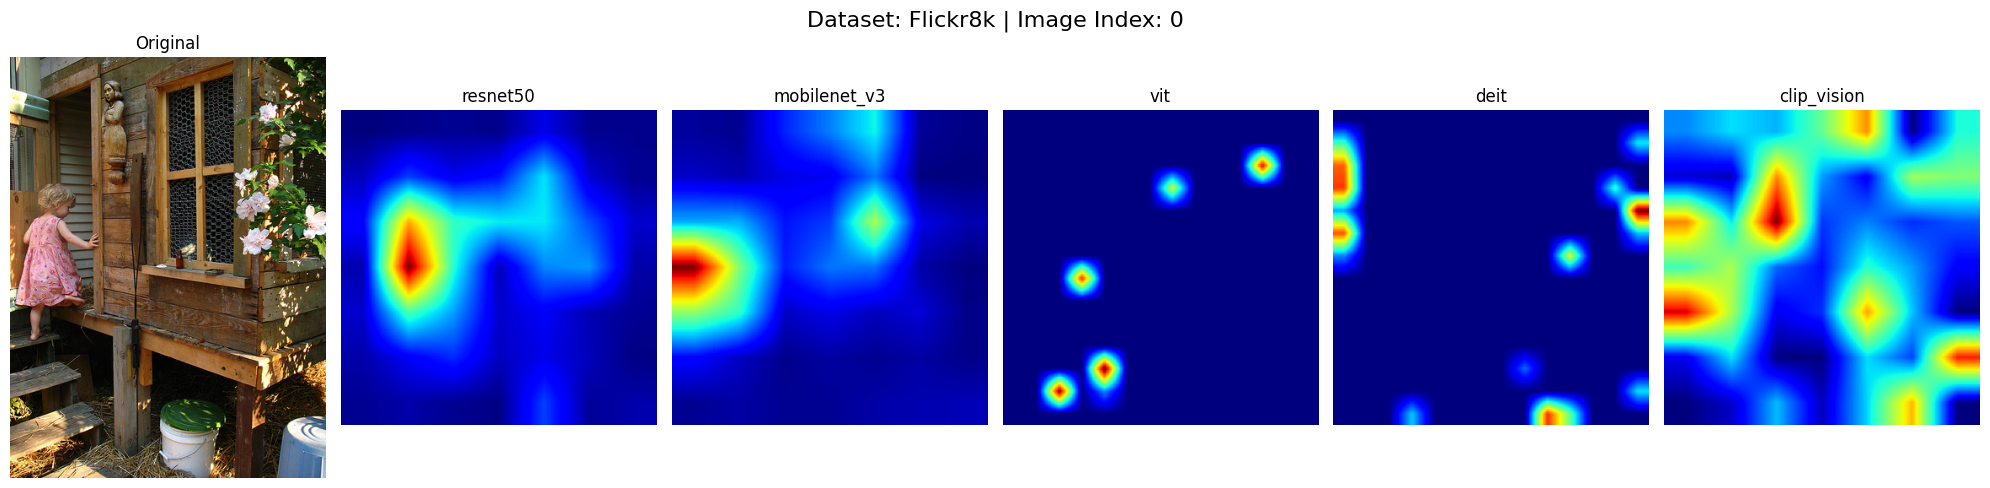

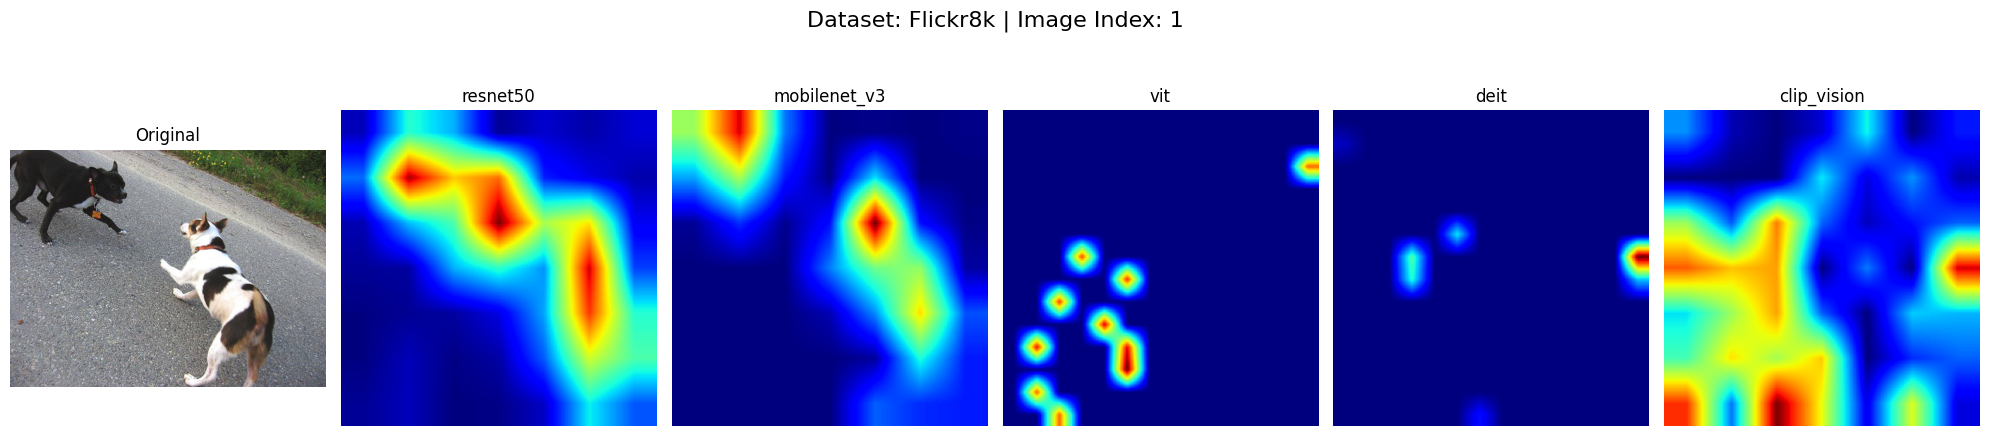


VALIDATING: Flickr30k


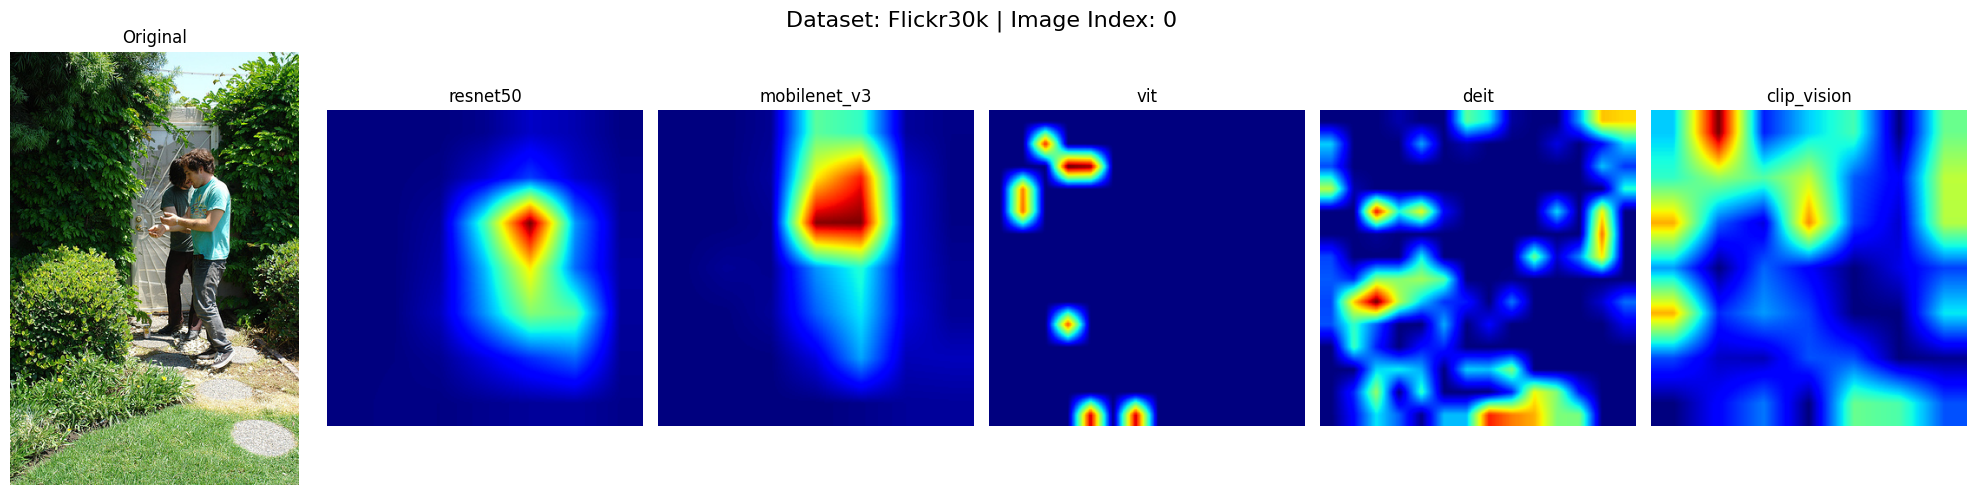

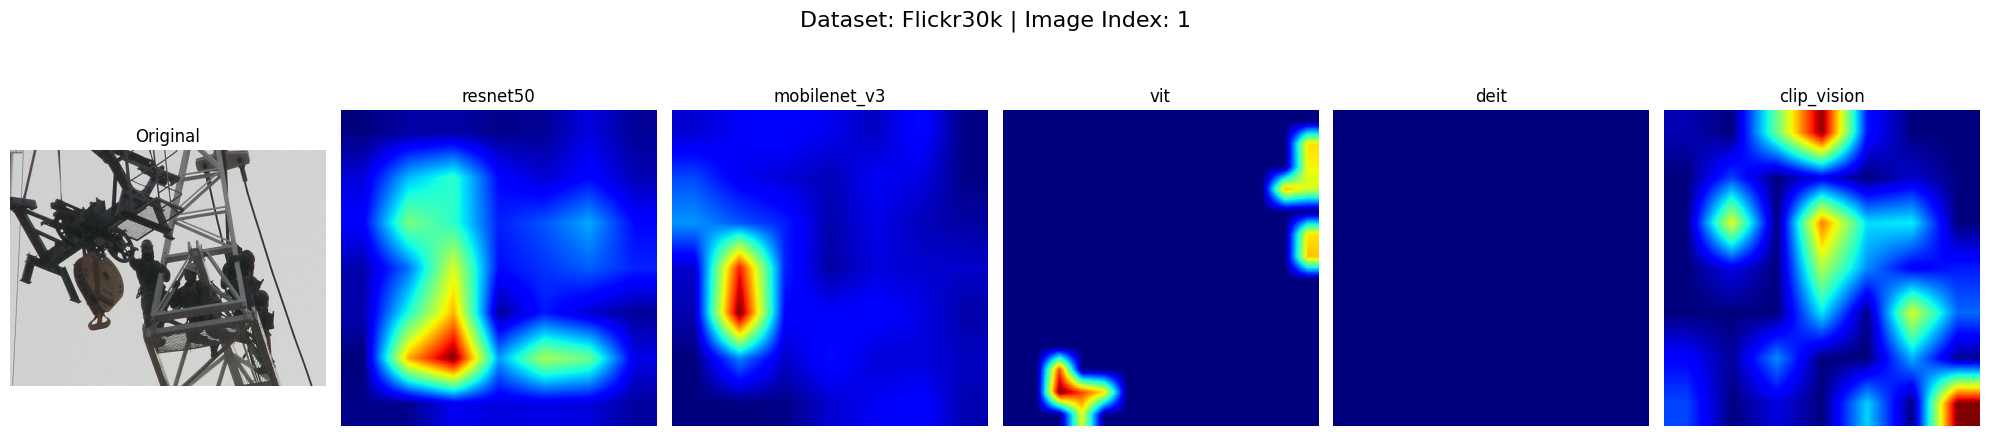


VALIDATING: ConceptualCaptions


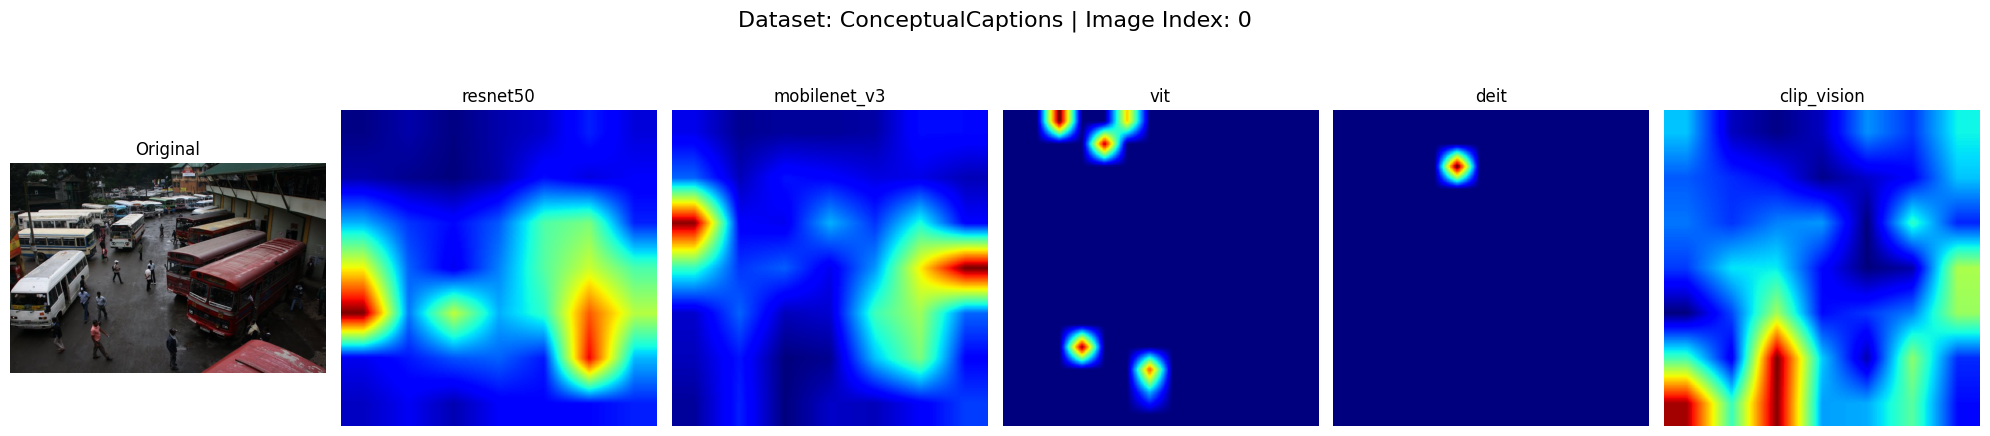

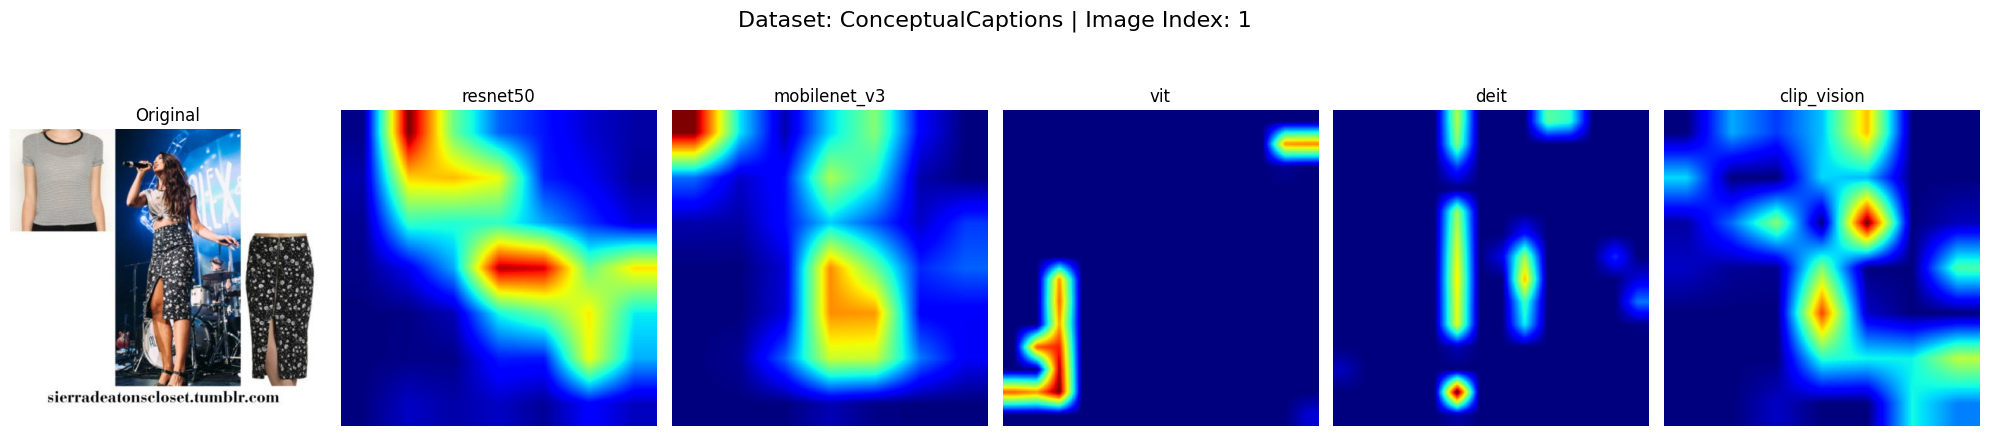

In [127]:
import matplotlib.pyplot as plt

def validate_saliency_maps(dataset_name, num_images=3):
    """
    Displays a comparison grid: Original Image vs. 5 Model Saliency Maps.
    """
    vision_models = ["resnet50", "mobilenet_v3", "vit", "deit", "clip_vision"]
    saliency_dir = os.path.join(DATA_DIR, f"SaliencyMaps_{dataset_name}")
    
    # Load dataset metadata to get original image paths
    df_path = os.path.join(DATASETS_DIR, f"df_{dataset_name}.pkl")
    df_temp = pd.read_pickle(df_path)
    
    for idx in range(num_images):
        img_path = df_temp.iloc[idx]['image_path']
        img_rgb = Image.open(img_path).convert('RGB')
        
        fig, axes = plt.subplots(1, 6, figsize=(20, 5))
        fig.suptitle(f"Dataset: {dataset_name} | Image Index: {idx}", fontsize=16)
        
        # 0. Original Image
        axes[0].imshow(img_rgb)
        axes[0].set_title("Original")
        axes[0].axis('off')
        
        # 1-5. Model Heatmaps
        for i, model in enumerate(vision_models):
            npy_file = os.path.join(saliency_dir, f"Saliency_{model}_{idx}.npy")
            
            if os.path.exists(npy_file):
                heatmap = np.load(npy_file)
                # Plot heatmap with 'jet' colormap for high contrast
                im = axes[i+1].imshow(heatmap, cmap='jet')
                axes[i+1].set_title(model)
            else:
                axes[i+1].text(0.5, 0.5, "MISSING", ha='center')
                
            axes[i+1].axis('off')
            
        plt.tight_layout()
        plt.show()

# Run the check for the first 2 images of each dataset
for ds in ALL_DATASETS:
    print(f"\nVALIDATING: {ds}")
    validate_saliency_maps(ds, num_images=2)

In [125]:
for ds in ALL_DATASETS:
    print(f"\nProcessing DeiT for {ds}...")
    df_patch = pd.read_pickle(os.path.join(DATASETS_DIR, f"df_{ds}.pkl"))
    patch_paths = df_patch['image_path'].tolist()
    execute_and_save("vision", "deit", lambda p, d: get_deit_embeddings(p, d, ds), patch_paths, device)

# Final Verification
print("DeiT files in Flickr8k:", len([f for f in os.listdir(os.path.join(DATA_DIR, 'SaliencyMaps_Flickr8k')) if 'deit' in f]))


Processing DeiT for Flickr8k...

Processing VISION with model: deit


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

DeiTModel LOAD REPORT from: facebook/deit-base-distilled-patch16-224
Key                            | Status     | 
-------------------------------+------------+-
distillation_classifier.bias   | UNEXPECTED | 
cls_classifier.weight          | UNEXPECTED | 
distillation_classifier.weight | UNEXPECTED | 
cls_classifier.bias            | UNEXPECTED | 
pooler.dense.weight            | MISSING    | 
pooler.dense.bias              | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


deit:   0%|          | 0/253 [00:00<?, ?it/s]

Saved RAW features to: /home/aysel/tfe/TFE_Data/Features_RAW/X_vision_deit_raw_ConceptualCaptions.npy

Processing DeiT for Flickr30k...

Processing VISION with model: deit


...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

DeiTModel LOAD REPORT from: facebook/deit-base-distilled-patch16-224
Key                            | Status     | 
-------------------------------+------------+-
distillation_classifier.bias   | UNEXPECTED | 
cls_classifier.weight          | UNEXPECTED | 
distillation_classifier.weight | UNEXPECTED | 
cls_classifier.bias            | UNEXPECTED | 
pooler.dense.weight            | MISSING    | 
pooler.dense.bias              | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


deit:   0%|          | 0/1563 [00:00<?, ?it/s]

The channel dimension is ambiguous. Got image shape (1, 1, 3). Assuming channels are the first dimension. Use the [input_data_format](https://huggingface.co/docs/transformers/main/internal/image_processing_utils#transformers.image_transforms.rescale.input_data_format) parameter to assign the channel dimension.
The channel dimension is ambiguous. Got image shape (1, 1, 3). Assuming channels are the first dimension. Use the [input_data_format](https://huggingface.co/docs/transformers/main/internal/image_processing_utils#transformers.image_transforms.rescale.input_data_format) parameter to assign the channel dimension.
The channel dimension is ambiguous. Got image shape (1, 1, 3). Assuming channels are the first dimension. Use the [input_data_format](https://huggingface.co/docs/transformers/main/internal/image_processing_utils#transformers.image_transforms.rescale.input_data_format) parameter to assign the channel dimension.
The channel dimension is ambiguous. Got image shape (1, 1, 3). A

Saved RAW features to: /home/aysel/tfe/TFE_Data/Features_RAW/X_vision_deit_raw_ConceptualCaptions.npy
DeiT files in Flickr8k: 8091


In [ ]:
def get_word_category(token):
    """Simple categorization for direct comparison."""
    # Common English stopwords (expand as needed for your thesis)
    stopwords = {'a', 'an', 'the', 'is', 'are', 'was', 'were', 'on', 'in', 'at', 'of', 'and', 'with', '[CLS]', '[SEP]', '<s>', '</s>', '<|endoftext|>'}
    clean_token = token.replace('##', '').replace('Ġ', '').lower()
    if clean_token in stopwords or not clean_token.isalnum():
        return "Grammar/Stopwords"
    return "Content (Nouns/Verbs)"

def calculate_semantic_density(img_idx, dataset_name, text_models_xai):
    saliency_dir = os.path.join(DATA_DIR, f"TextSaliency_{dataset_name}")
    results = []

    for model in text_models_xai:
        path = os.path.join(saliency_dir, f"SaliencyText_{model}_{img_idx}.npy")
        if not os.path.exists(path):
            print(f"⚠️ Missing saliency for {model} at index {img_idx}")
            continue

        data = np.load(path, allow_pickle=True).item()
        tokens, scores = data['tokens'], data['scores']

        content_sum, grammar_sum = 0, 0
        for t, s in zip(tokens, scores):
            cat = get_word_category(t)
            if cat == "Content (Nouns/Verbs)":
                content_sum += s
            else:
                grammar_sum += s

        total = content_sum + grammar_sum
        if total > 0:
            results.append({
                "Model": model.upper(),
                "Content (%)": (content_sum / total) * 100,
                "Grammar (%)": (grammar_sum / total) * 100
            })

    if len(results) == 0:
        print("No saliency results found. Cannot plot.")
        return pd.DataFrame()

    df_density = pd.DataFrame(results)
    df_density.set_index("Model").plot(
        kind='bar', stacked=True, figsize=(10, 6),
        color=['#2c3e50', '#95a5a6']
    )
    plt.title(f"Semantic Density Comparison (Index: {img_idx})", fontweight='bold')
    plt.ylabel("Percentage of Total Attribution")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    return df_density

In [21]:
def aggregate_to_words(tokens, scores):
    """Aggregates sub-token scores into full word scores for direct comparison."""
    words = []
    word_scores = []
    current_word = ""
    current_score = 0
    count = 0

    for t, s in zip(tokens, scores):
        # Handle BERT (##) and RoBERTa/GPT2 (Ġ) sub-tokens
        is_subtoken = t.startswith("##") or (not t.startswith("Ġ") and count > 0 and "clip" not in t) 
        # Note: Logic varies by tokenizer, this is a generalized heuristic
        
        if is_subtoken:
            current_word += t.replace("##", "")
            current_score = max(current_score, s) # Take the max importance of sub-tokens
        else:
            if current_word:
                words.append(current_word.replace("Ġ", ""))
                word_scores.append(current_score)
            current_word = t
            current_score = s
        count += 1
    
    words.append(current_word.replace("Ġ", ""))
    word_scores.append(current_score)
    return words, word_scores

def calculate_model_correlation(img_idx, dataset_name, text_models):
    """
    Computes Spearman Correlation between the saliency rankings of different models.
    """
    saliency_dir = os.path.join(DATA_DIR, f"TextSaliency_{dataset_name}")
    model_data = {}

    for model in text_models:
        path = os.path.join(saliency_dir, f"SaliencyText_{model}_{img_idx}.npy")
        if os.path.exists(path):
            data = np.load(path, allow_pickle=True).item()
            # Aggregate to words so we compare the same units
            words, scores = aggregate_to_words(data['tokens'], data['scores'])
            model_data[model] = scores

    # Create correlation matrix
    names = list(model_data.keys())
    matrix = np.zeros((len(names), len(names)))

    for i, name1 in enumerate(names):
        for j, name2 in enumerate(names):
            # We compare ranks of words
            s1, s2 = model_data[name1], model_data[name2]
            # Ensure lengths match (truncate to shortest for comparison)
            min_len = min(len(s1), len(s2))
            corr, _ = spearmanr(s1[:min_len], s2[:min_len])
            matrix[i, j] = corr

    plt.figure(figsize=(8, 6))
    sns.heatmap(matrix, annot=True, xticklabels=[n.upper() for n in names], yticklabels=[n.upper() for n in names], cmap="coolwarm", center=0)
    plt.title(f"XAI Rank Correlation (Spearman) | Index: {img_idx}")
    plt.show()

In [ ]:
text_models_xai = ['bert', 'roberta', 'gpt2']  # modèles pour XAI
all_datasets = ['Flickr8k', 'Flickr30k', 'ConceptualCaptions']  # liste de tes datasets textuels

for ds_name in all_datasets:
    print(f"\n{'='*20}\nProcessing Dataset: {ds_name}\n{'='*20}")
    
    # Assurez-vous que DATA_DIR existe
    dataset_texts = load_texts(ds_name)  # tu dois définir cette fonction pour récupérer les textes
    ds_dir = os.path.join(DATA_DIR, f"TextSaliency_{ds_name}")
    os.makedirs(ds_dir, exist_ok=True)
    
    for model_name in text_models_xai:
        print(f"\n--- Extracting {model_name.upper()} embeddings and saliency ---")
        
        if model_name == 'bert':
            feats = get_bert_embeddings_xai(dataset_texts, device, ds_name)
        elif model_name == 'roberta':
            feats = get_roberta_embeddings_xai(dataset_texts, device, ds_name)
        elif model_name == 'gpt2':
            feats = get_gpt2_embeddings_xai(dataset_texts, device, ds_name)
        
        # Créer sous-dossier par modèle
        model_dir = os.path.join(ds_dir, model_name)
        os.makedirs(model_dir, exist_ok=True)
        
        # Les fichiers saliency ont déjà été sauvegardés dans extract_text_features_with_saliency
        # Optionnel : sauvegarde des embeddings globaux
        np.save(os.path.join(model_dir, f"{model_name}_embeddings_{ds_name}.npy"), feats)
    
    # Notification ntfy pour la fin du dataset
    send_ntfy_notification(
        f"Text XAI completed for dataset {ds_name}. Embeddings & saliency maps saved.",
        "TFE Text Pipeline Finished"
    )

In [19]:
calculate_semantic_density(
    img_idx=0,
    dataset_name="Flickr8k",
    text_models=["bert", "roberta", "gpt2", "clip_text"]
)

⚠️ Missing saliency for bert at index 0
⚠️ Missing saliency for roberta at index 0
⚠️ Missing saliency for gpt2 at index 0
⚠️ Missing saliency for clip_text at index 0
No saliency results found. Cannot plot.


""


In [17]:
calculate_model_correlation(
    img_idx=0,
    dataset_name="Flickr8k",
    text_models=["bert", "roberta", "gpt2", "clip_text"]
)

ValueError: zero-size array to reduction operation fmin which has no identity

<Figure size 800x600 with 0 Axes>